# Phase 34 — Stemming & Lemmatization

Δοκιμή stemming και lemmatization στα classical models.

**Stemming:** Κόβει κατάληξη λέξης με κανόνες
- 'running' → 'run', 'recalled' → 'recal', 'listeria' → 'listeri'
- Γρήγορο αλλά μερικές φορές παράγει non-words

**Lemmatization:** Βρίσκει τη βασική μορφή λέξης με λεξικό
- 'running' → 'run', 'recalled' → 'recall', 'better' → 'good'
- Πιο αργό αλλά παράγει πάντα σωστές λέξεις

**Υπόθεση:** Για food safety domain το stemming/lemmatization μπορεί
να βλάψει γιατί λέξεις όπως 'salmonella', 'listeria' είναι ήδη στη
βασική τους μορφή και το stemming τις αλλοιώνει.

**Baseline:** TF-IDF + SVM = 0.7419

In [2]:
#!pip install nltk -q
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [3]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import f1_score
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk
import warnings
warnings.filterwarnings('ignore')



In [4]:
train = pd.read_csv('train.csv')
valid = pd.read_csv('valid.csv')
test  = pd.read_csv('test.csv')

def base_preprocess(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def make_text(df):
    return (df['title'].apply(base_preprocess) + ' ' +
            df['text'].str[:550].apply(base_preprocess)).tolist()

# Base texts (χωρίς stemming/lemmatization)
texts_train_base = make_text(train)
texts_valid_base = make_text(valid)
texts_test_base  = make_text(test)

print(f'Train: {len(train)} | Valid: {len(valid)} | Test: {len(test)}')
print(f'\nΠαράδειγμα text (πρώτες 100 chars):')
print(texts_train_base[0][:100])

Train: 5082 | Valid: 565 | Test: 997

Παράδειγμα text (πρώτες 100 chars):
recall notification fsis case number date opened date closed recall class press release y n y domest


In [5]:
# Stemmer/Lemmatizer setup
porter   = PorterStemmer()
snowball = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Βρίσκει το POS tag για lemmatization."""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {'J': wordnet.ADJ, 'N': wordnet.NOUN,
                'V': wordnet.VERB, 'R': wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def apply_porter(texts):
    return [' '.join([porter.stem(w) for w in t.split()]) for t in texts]

def apply_snowball(texts):
    return [' '.join([snowball.stem(w) for w in t.split()]) for t in texts]

def apply_lemmatizer(texts):
    result = []
    for text in texts:
        words = text.split()
        lemmatized = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in words]
        result.append(' '.join(lemmatized))
    return result

# Παράδειγμα
sample = 'recalled products containing salmonella bacteria causing infections'
print(f'Original:    {sample}')
print(f'Porter:      {apply_porter([sample])[0]}')
print(f'Snowball:    {apply_snowball([sample])[0]}')
print(f'Lemmatizer:  {apply_lemmatizer([sample])[0]}')

Original:    recalled products containing salmonella bacteria causing infections
Porter:      recal product contain salmonella bacteria caus infect
Snowball:    recal product contain salmonella bacteria caus infect
Lemmatizer:  recall product contain salmonella bacteria cause infection


In [6]:
# Εφαρμογή σε όλα τα texts
print('Porter Stemmer')
texts_train_porter   = apply_porter(texts_train_base)
texts_valid_porter   = apply_porter(texts_valid_base)
texts_test_porter    = apply_porter(texts_test_base)

print('Snowball Stemmer')
texts_train_snowball = apply_snowball(texts_train_base)
texts_valid_snowball = apply_snowball(texts_valid_base)
texts_test_snowball  = apply_snowball(texts_test_base)

print('Lemmatizer')
texts_train_lemma = apply_lemmatizer(texts_train_base)
texts_valid_lemma = apply_lemmatizer(texts_valid_base)
texts_test_lemma  = apply_lemmatizer(texts_test_base)


Porter Stemmer
Snowball Stemmer
Lemmatizer


In [7]:
def official_st1_score(y_true_h, y_pred_h, y_true_p, y_pred_p, verbose=False):
    f1_h = f1_score(y_true_h, y_pred_h, average='macro', zero_division=0)
    mask = (np.array(y_true_h) == np.array(y_pred_h))
    f1_p = f1_score(
        np.array(y_true_p)[mask], np.array(y_pred_p)[mask],
        average='macro', zero_division=0
    ) if mask.sum() > 0 else 0.0
    score = (f1_h + f1_p) / 2
    if verbose:
        print(f'  macro-F1 Hazard:  {f1_h:.4f}')
        print(f'  macro-F1 Product: {f1_p:.4f}')
        print(f'  ST1 SCORE:        {score:.4f}')
    return score


def evaluate_texts(texts_train, texts_valid, label):
    tfidf = TfidfVectorizer(
        max_features=50000, ngram_range=(1,2),
        sublinear_tf=True, stop_words='english'
    )
    X_tr = tfidf.fit_transform(texts_train)
    X_va = tfidf.transform(texts_valid)

    clf_h = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_h.fit(X_tr, train['hazard-category'])
    clf_p = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_p.fit(X_tr, train['product-category'])

    score = official_st1_score(
        valid['hazard-category'], clf_h.predict(X_va),
        valid['product-category'], clf_p.predict(X_va)
    )
    print(f'{label:25s}: {score:.4f}')
    return score, tfidf, clf_h, clf_p


print('=== ΣΥΓΚΡΙΣΗ TF-IDF + SVM ===\n')
score_base,     *_ = evaluate_texts(texts_train_base,     texts_valid_base,     'Baseline (no stemming)')
score_porter,   *_ = evaluate_texts(texts_train_porter,   texts_valid_porter,   'Porter Stemmer')
score_snowball, *_ = evaluate_texts(texts_train_snowball, texts_valid_snowball, 'Snowball Stemmer')
score_lemma,    *_ = evaluate_texts(texts_train_lemma,    texts_valid_lemma,    'Lemmatizer')

=== ΣΥΓΚΡΙΣΗ TF-IDF + SVM ===

Baseline (no stemming)   : 0.7436
Porter Stemmer           : 0.7421
Snowball Stemmer         : 0.7428
Lemmatizer               : 0.7404


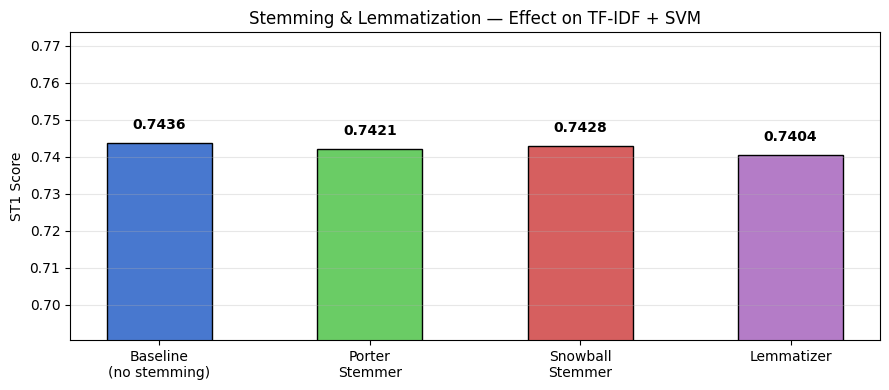

Αποθηκεύτηκε: stemming_comparison.png

Βέλτιστη μέθοδος: Baseline (no stemming) (0.7436)
Συμπέρασμα: Το stemming/lemmatization δεν βοηθάει — η baseline είναι καλύτερη


In [8]:
# Visualization
labels = ['Baseline\n(no stemming)', 'Porter\nStemmer', 'Snowball\nStemmer', 'Lemmatizer']
scores = [score_base, score_porter, score_snowball, score_lemma]
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, scores, color=colors, edgecolor='black', width=0.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('ST1 Score')
ax.set_title('Stemming & Lemmatization — Effect on TF-IDF + SVM')
ax.set_ylim(min(scores) - 0.05, max(scores) + 0.03)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('stemming_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: stemming_comparison.png')

best_method = labels[np.argmax(scores)].replace('\n', ' ')
print(f'\nΒέλτιστη μέθοδος: {best_method} ({max(scores):.4f})')
print(f'Συμπέρασμα: {"Το stemming/lemmatization βοηθάει" if max(scores) > score_base else "Το stemming/lemmatization δεν βοηθάει — η baseline είναι καλύτερη"}')

In [9]:
# Submission με τη βέλτιστη μέθοδο
best_idx = np.argmax(scores)
best_texts_test = [texts_test_base, texts_test_porter,
                   texts_test_snowball, texts_test_lemma][best_idx]
best_texts_train = [texts_train_base, texts_train_porter,
                    texts_train_snowball, texts_train_lemma][best_idx]

tfidf_best = TfidfVectorizer(
    max_features=50000, ngram_range=(1,2),
    sublinear_tf=True, stop_words='english'
)
X_tr = tfidf_best.fit_transform(best_texts_train)
X_te = tfidf_best.transform(best_texts_test)

clf_h_best = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
clf_h_best.fit(X_tr, train['hazard-category'])
clf_p_best = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
clf_p_best.fit(X_tr, train['product-category'])

pd.DataFrame({
    'id': test['id'],
    'hazard-category':  clf_h_best.predict(X_te),
    'product-category': clf_p_best.predict(X_te)
}).to_csv('submission_stemming.csv', index=False)

print(f'Αποθηκεύτηκε: submission_stemming.csv ({best_method})')

Αποθηκεύτηκε: submission_stemming.csv (Baseline (no stemming))
